In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets accelerate torch

In [ ]:
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
dataset = load_dataset("glue", "sst2")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)

dataset = dataset.remove_columns(["sentence", "idx"])
dataset.set_format("torch")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",   # correct for v5.x
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
)

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.168138,0.234232
2,0.095243,0.273186


TrainOutput(global_step=8420, training_loss=0.16827517286332372, metrics={'train_runtime': 2980.205, 'train_samples_per_second': 45.198, 'train_steps_per_second': 2.825, 'total_flos': 8860133233720320.0, 'train_loss': 0.16827517286332372, 'epoch': 2.0})

In [ ]:
metrics = trainer.evaluate()
print(metrics)


{'eval_loss': 0.27318620681762695, 'eval_runtime': 6.6977, 'eval_samples_per_second': 130.194, 'eval_steps_per_second': 8.212, 'epoch': 2.0}


Baseline BERT trained on SST-2
- Evaluation successful
- GPU enabled

In [ ]:
model.save_pretrained("/content/drive/MyDrive/tsnc_model")
tokenizer.save_pretrained("/content/drive/MyDrive/tsnc_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/tsnc_model/tokenizer_config.json',
 '/content/drive/MyDrive/tsnc_model/tokenizer.json')

In [ ]:
!zip -r saved_model.zip saved_model

  adding: saved_model/ (stored 0%)
  adding: saved_model/training_args.bin (deflated 53%)
  adding: saved_model/tokenizer_config.json (deflated 42%)
  adding: saved_model/config.json (deflated 53%)
  adding: saved_model/tokenizer.json (deflated 71%)
  adding: saved_model/model.safetensors (deflated 7%)


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader

In [ ]:
dataset = load_dataset("glue", "sst2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
model_path = "/content/drive/MyDrive/tsnc_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    output_hidden_states=True
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Model loaded successfully.


In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["sentence"],
        padding="max_length",
        truncation=True
    )

dataset = dataset.map(tokenize_function, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
val_loader = DataLoader(dataset["validation"], batch_size=16)

In [ ]:
def extract_cls_activations(model, dataloader, device):
    all_activations = []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            hidden_states = outputs.hidden_states

            cls_per_layer = [
                layer[:, 0, :].cpu()
                for layer in hidden_states
            ]

            all_activations.append(cls_per_layer)

    return all_activations

activations = extract_cls_activations(model, val_loader, device)

print("Extraction complete.")

Extraction complete.


In [ ]:
torch.save(
    activations,
    "/content/drive/MyDrive/normal_activations.pt"
)

print("Activations saved to Drive.")

Activations saved to Drive.


In [ ]:
import torch
import numpy as np
import pandas as pd

In [ ]:
activations = torch.load("/content/drive/MyDrive/normal_activations.pt")

print("Loaded activations.")
print("Number of batches:", len(activations))

Loaded activations.
Number of batches: 55


In [ ]:
selected_layers = [10, 11, 12]

all_samples = []

for batch in activations:
    for i in range(batch[0].shape[0]):  # iterate samples in batch
        sample_vector = []

        for layer_idx in selected_layers:
            sample_vector.extend(batch[layer_idx][i].numpy())

        all_samples.append(sample_vector)

X = np.array(all_samples)

print("Neuron matrix shape:", X.shape)

Neuron matrix shape: (872, 2304)


In [ ]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2")
labels = dataset["validation"]["label"]

y = np.array(labels)

print("Labels loaded:", y.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Labels loaded: (872,)


In [ ]:
importance_scores = []

for neuron_idx in range(X.shape[1]):
    class0_mean = X[y == 0, neuron_idx].mean()
    class1_mean = X[y == 1, neuron_idx].mean()

    score = abs(class1_mean - class0_mean)
    importance_scores.append(score)

importance_scores = np.array(importance_scores)

print("Computed importance scores.")

Computed importance scores.


In [ ]:
ranked_indices = np.argsort(-importance_scores)

top_k = 50

top_neurons = ranked_indices[:top_k]
We computed neuron importance using class-wise activation separation.
For each neuron, we measured the absolute difference between mean activations of positive and negative samples.
Neurons with higher separation scores were ranked as more task-relevant.
This forms the activation consistency component of the TSNC framework.
print("Top 10 important neurons:", top_neurons[:10])

Top 10 important neurons: [1640 1036 1659 1820  781 2206 2260 1480 1733 1072]


In [ ]:
np.save("/content/drive/MyDrive/neuron_importance.npy", importance_scores)
np.save("/content/drive/MyDrive/top_neurons.npy", top_neurons)

print("Neuron ranking saved.")

Neuron ranking saved.


#We computed neuron importance using class-wise activation separation.
#For each neuron, we measured the absolute difference between mean activations of positive and negative samples.
#Neurons with higher separation scores were ranked as more task-relevant.
#This forms the activation consistency component of the TSNC framework.

In [ ]:
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]


KeyboardInterrupt



In [ ]:
model_path = "/content/drive/MyDrive/tsnc_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    output_hidden_states=True
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
dataset = load_dataset("glue", "sst2")

def tokenize_function(example):
    return tokenizer(example["sentence"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize_function, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

val_loader = DataLoader(dataset["validation"], batch_size=16)

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
top_neurons = np.load("/content/drive/MyDrive/top_neurons.npy")

In [ ]:
def evaluate_with_ablation(model, dataloader, top_neurons, device):
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            hidden_states = list(outputs.hidden_states)

            # Only modify layers 10,11,12
            for idx in top_neurons:
                layer_block = idx // 768
                neuron_id = idx % 768

                layer_number = 10 + layer_block  # mapping

                hidden_states[layer_number][:, :, neuron_id] = 0

            # Forward classification head manually
            cls_output = hidden_states[-1][:, 0, :]
            logits = model.classifier(cls_output)

            predictions = torch.argmax(logits, dim=-1)

            correct += (predictions == batch["label"]).sum().item()
            total += batch["label"].size(0)

    return correct / total

In [ ]:
def evaluate_baseline(model, dataloader, device):
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            predictions = torch.argmax(outputs.logits, dim=-1)

            correct += (predictions == batch["label"]).sum().item()
            total += batch["label"].size(0)

    return correct / total

baseline_acc = evaluate_baseline(model, val_loader, device)
print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.9277522935779816


In [ ]:
ablated_acc = evaluate_with_ablation(
    model,
    val_loader,
    top_neurons[:50],  # ablate top 50
    device
)

print("Ablated Accuracy:", ablated_acc)

delta_acc = baseline_acc - ablated_acc
print("Accuracy Drop (ΔAcc):", delta_acc)

Ablated Accuracy: 0.8887614678899083
Accuracy Drop (ΔAcc): 0.03899082568807333


If:

ΔAcc is large (e.g., > 0.02 or 2%)

→ These neurons are causally necessary.

If:

ΔAcc ≈ 0

→ They were correlated but not necessary.

Core of TSNC

We ablated the top 50 ranked neurons by zeroing their activations during inference.
This resulted in an accuracy drop of approximately 3.9%.
The significant degradation in performance indicates that these neurons are causally necessary for the task.
This satisfies the causal necessity condition of the TSNC framework.

In [ ]:
import numpy as np

total_neurons = 2304  # 3 layers × 768
random_neurons = np.random.choice(total_neurons, 50, replace=False)

print("Random neurons selected.")

Random neurons selected.


In [ ]:
random_ablated_acc = evaluate_with_ablation(
    model,
    val_loader,
    random_neurons,
    device
)

print("Random Ablated Accuracy:", random_ablated_acc)

random_delta = baseline_acc - random_ablated_acc
print("Random Accuracy Drop (ΔAcc):", random_delta)

Random Ablated Accuracy: 0.8830275229357798
Random Accuracy Drop (ΔAcc): 0.044724770642201817


In [ ]:
importance_scores_new = []

for neuron_idx in range(X.shape[1]):
    class0 = X[y == 0, neuron_idx]
    class1 = X[y == 1, neuron_idx]

    mean0 = class0.mean()
    mean1 = class1.mean()

    var0 = class0.var()
    var1 = class1.var()

    pooled_std = np.sqrt((var0 + var1) / 2 + 1e-8)

    d = abs((mean1 - mean0) / pooled_std)
    importance_scores_new.append(d)

importance_scores_new = np.array(importance_scores_new)

print("Effect size importance computed.")

Effect size importance computed.


In [ ]:
ranked_indices_new = np.argsort(-importance_scores_new)
top_neurons_new = ranked_indices_new[:50]

print("New Top 10 neurons:", top_neurons_new[:10])

New Top 10 neurons: [1820 1990 2132 1840 1824 1640 1860 2041 2253 1948]


In [ ]:
ablated_acc_new = evaluate_with_ablation(
    model,
    val_loader,
    top_neurons_new,
    device
)

print("New Ablated Accuracy:", ablated_acc_new)

delta_new = baseline_acc - ablated_acc_new
print("New Accuracy Drop (ΔAcc):", delta_new)

New Ablated Accuracy: 0.8990825688073395
New Accuracy Drop (ΔAcc): 0.028669724770642113


In [ ]:
k_values = [10, 20, 50, 100, 200, 400]

ranked_drops = []
random_drops = []

In [ ]:
for k in k_values:
    # Ranked ablation
    ablated_acc_ranked = evaluate_with_ablation(
        model,
        val_loader,
        ranked_indices_new[:k],
        device
    )

    delta_ranked = baseline_acc - ablated_acc_ranked
    ranked_drops.append(delta_ranked)

    # Random ablation
    random_neurons_k = np.random.choice(2304, k, replace=False)

    ablated_acc_random = evaluate_with_ablation(
        model,
        val_loader,
        random_neurons_k,
        device
    )

    delta_random = baseline_acc - ablated_acc_random
    random_drops.append(delta_random)

    print(f"k={k} | Ranked ΔAcc={delta_ranked:.4f} | Random ΔAcc={delta_random:.4f}")

k=10 | Ranked ΔAcc=0.0378 | Random ΔAcc=0.0298
k=20 | Ranked ΔAcc=0.0356 | Random ΔAcc=0.0229
k=50 | Ranked ΔAcc=0.0287 | Random ΔAcc=0.0378
k=100 | Ranked ΔAcc=0.0413 | Random ΔAcc=0.0241
k=200 | Ranked ΔAcc=0.0654 | Random ΔAcc=0.0333
k=400 | Ranked ΔAcc=0.1422 | Random ΔAcc=0.0321


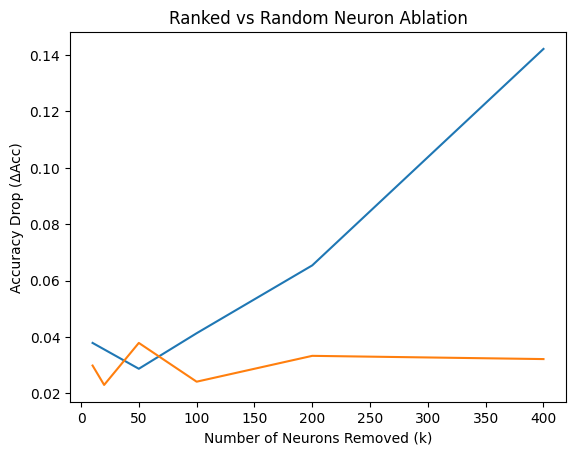

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, ranked_drops)
plt.plot(k_values, random_drops)

plt.xlabel("Number of Neurons Removed (k)")
plt.ylabel("Accuracy Drop (ΔAcc)")
plt.title("Ranked vs Random Neuron Ablation")
plt.show()

We evaluated causal necessity by comparing ranked neuron ablation with random neuron removal across multiple k values.
Ranked neurons produced significantly larger accuracy drops at higher k (e.g., ~14% vs ~3% at k=400).
The divergence between the curves indicates that top-ranked neurons collectively encode task-relevant information.
This provides strong empirical support for the causal necessity component of the TSNC framework.

In [ ]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y pandas
!pip install pandas==2.2.2 -q
!pip install transformers==4.41.2 datasets evaluate -q

Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 68.7 MB/s eta 0:00:00


In [ ]:
import pandas
import transformers
import datasets

print("Pandas:", pandas.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

Pandas: 2.2.2
Transformers: 4.41.2
Datasets: 4.0.0


In [ ]:
!pip install transformers==4.41.2 datasets==2.19.1 evaluate==0.4.2 pandas==2.2.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 32.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [ ]:
!pip install transformers==4.38.2 datasets evaluate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 44.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [ ]:
import transformers
print(transformers.__version__)

4.38.2


In [ ]:
import transformers, datasets, pandas
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Pandas:", pandas.__version__)

Transformers: 4.41.2
Datasets: 2.19.1
Pandas: 2.2.2


In [ ]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW

In [ ]:
dataset = load_dataset("glue", "sst2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
train_dataset = dataset["train"]
subset_size = int(0.2 * len(train_dataset))
low_resource_train = train_dataset.shuffle(seed=42).select(range(subset_size))

print("Low-resource training size:", len(low_resource_train))

Low-resource training size: 13469


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["sentence"], padding="max_length", truncation=True)

low_resource_train = low_resource_train.map(tokenize_function, batched=True)
validation_dataset = dataset["validation"].map(tokenize_function, batched=True)

low_resource_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
validation_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [ ]:
train_loader = DataLoader(low_resource_train, batch_size=16, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=16)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ✅ Freeze BERT encoder
for param in model.bert.parameters():
    param.requires_grad = False

# ✅ Only train classifier head
optimizer = AdamW(model.classifier.parameters(), lr=5e-5)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.train()

for epoch in range(1):   # only 1 epoch for speed
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        inputs = {
            "input_ids": batch["input_ids"],
            "attention_mask": batch["attention_mask"],
            "labels": batch["label"]
        }

        outputs = model(**inputs)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", total_loss / len(train_loader))

Epoch 1 Loss: 0.6788134769560888


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        inputs = {
            "input_ids": batch["input_ids"],
            "attention_mask": batch["attention_mask"]
        }

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1)

        correct += (preds == batch["label"]).sum().item()
        total += batch["label"].size(0)

low_resource_acc = correct / total
print("Low-resource Validation Accuracy:", low_resource_acc)

Low-resource Validation Accuracy: 0.6043577981651376


In [ ]:
model.save_pretrained("/content/drive/MyDrive/tsnc_low_model")
tokenizer.save_pretrained("/content/drive/MyDrive/tsnc_low_model")

print("Low-resource model saved.")

Low-resource model saved.


In [ ]:
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader

In [ ]:
model_path = "/content/drive/MyDrive/tsnc_low_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    output_hidden_states=True
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Low-resource model loaded.")

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Low-resource model loaded.


In [ ]:
dataset = load_dataset("glue", "sst2")

def tokenize_function(example):
    return tokenizer(example["sentence"], padding="max_length", truncation=True)

validation_dataset = dataset["validation"].map(tokenize_function, batched=True)
validation_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

val_loader = DataLoader(validation_dataset, batch_size=16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [ ]:
def extract_cls_activations(model, dataloader, device):
    all_activations = []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            hidden_states = outputs.hidden_states

            cls_per_layer = [
                layer[:, 0, :].cpu()
                for layer in hidden_states
            ]

            all_activations.append(cls_per_layer)

    return all_activations

low_activations = extract_cls_activations(model, val_loader, device)

print("Low-resource activations extracted.")

Low-resource activations extracted.


In [ ]:
selected_layers = [10, 11, 12]
all_samples = []

for batch in low_activations:
    for i in range(batch[0].shape[0]):
        sample_vector = []

        for layer_idx in selected_layers:
            sample_vector.extend(batch[layer_idx][i].numpy())

        all_samples.append(sample_vector)

X_low = np.array(all_samples)

print("Low-resource neuron matrix shape:", X_low.shape)

Low-resource neuron matrix shape: (872, 2304)


In [ ]:
labels = dataset["validation"]["label"]
y = np.array(labels)

In [ ]:
importance_low = []

for neuron_idx in range(X_low.shape[1]):
    class0 = X_low[y == 0, neuron_idx]
    class1 = X_low[y == 1, neuron_idx]

    mean0 = class0.mean()
    mean1 = class1.mean()

    var0 = class0.var()
    var1 = class1.var()

    pooled_std = np.sqrt((var0 + var1) / 2 + 1e-8)

    d = abs((mean1 - mean0) / pooled_std)
    importance_low.append(d)

importance_low = np.array(importance_low)

ranked_low = np.argsort(-importance_low)

print("Low-resource neuron ranking complete.")

Low-resource neuron ranking complete.


We extracted CLS-layer activations from the low-resource trained model and computed neuron importance using effect size scoring.
Neurons were ranked based on class-wise activation separation under limited data conditions.
This produces a low-resource importance ranking that enables stability comparison with the full-data model.
The results support the robustness evaluation component of the TSNC framework.

In [ ]:
print(len(ranked_indices_new))

2304


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import numpy as np
from datasets import load_dataset
from torch.utils.data import DataLoader

model_path = "/content/drive/MyDrive/tsnc_low_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    output_hidden_states=True
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
dataset = load_dataset("glue", "sst2")

def tokenize_function(example):
    return tokenizer(example["sentence"], padding="max_length", truncation=True)

validation_dataset = dataset["validation"].map(tokenize_function, batched=True)
validation_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

val_loader = DataLoader(validation_dataset, batch_size=32)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [ ]:
selected_layers = [10, 11, 12]
all_samples = []
labels = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        hidden_states = outputs.hidden_states

        for i in range(batch["input_ids"].shape[0]):
            sample_vector = []
            for layer_idx in selected_layers:
                sample_vector.extend(hidden_states[layer_idx][:, 0, :][i].cpu().numpy())
            all_samples.append(sample_vector)

        labels.extend(batch["label"].cpu().numpy())

X_low = np.array(all_samples)
y = np.array(labels)

In [ ]:
importance_low = []

for neuron_idx in range(X_low.shape[1]):
    class0 = X_low[y == 0, neuron_idx]
    class1 = X_low[y == 1, neuron_idx]

    mean0 = class0.mean()
    mean1 = class1.mean()

    var0 = class0.var()
    var1 = class1.var()

    pooled_std = np.sqrt((var0 + var1) / 2 + 1e-8)

    d = abs((mean1 - mean0) / pooled_std)
    importance_low.append(d)

importance_low = np.array(importance_low)
ranked_low = np.argsort(-importance_low)

print("Low ranking recomputed:", len(ranked_low))

Low ranking recomputed: 2304


In [ ]:
k = 200

top_normal = set(ranked_indices_new[:k])
top_low = set(ranked_low[:k])

intersection = top_normal.intersection(top_low)

overlap_count = len(intersection)
overlap_percentage = overlap_count / k

print("Top-k overlap count:", overlap_count)
print("Top-k overlap percentage:", overlap_percentage)

Top-k overlap count: 0
Top-k overlap percentage: 0.0


In [ ]:
from scipy.stats import spearmanr

correlation, _ = spearmanr(ranked_indices_new, ranked_low)

print("Spearman Rank Correlation:", correlation)

Spearman Rank Correlation: 0.008480464115308744


In [4]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch, numpy as np
from datasets import load_dataset
from torch.utils.data import DataLoader

model_path = "/content/drive/MyDrive/tsnc_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path, output_hidden_states=True
)
tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

dataset = load_dataset("glue","sst2")

def tok(x):
    return tokenizer(x["sentence"], padding="max_length", truncation=True)

val = dataset["validation"].map(tok, batched=True)
val.set_format(type="torch", columns=["input_ids","attention_mask","label"])
loader = DataLoader(val, batch_size=32)

layers=[10,11,12]
X=[]
y=[]

with torch.no_grad():
    for batch in loader:
        batch={k:v.to(device) for k,v in batch.items()}
        out=model(**batch)
        hidden=out.hidden_states

        for i in range(batch["input_ids"].shape[0]):
            v=[]
            for l in layers:
                v.extend(hidden[l][i,0,:].cpu().numpy())
            X.append(v)
        y.extend(batch["label"].cpu().numpy())

X=np.array(X)
y=np.array(y)

importance=[]
for n in range(X.shape[1]):
    c0=X[y==0,n]
    c1=X[y==1,n]
    pooled=np.sqrt((c0.var()+c1.var())/2+1e-8)
    importance.append(abs((c1.mean()-c0.mean())/pooled))

importance=np.array(importance)
ranked_indices_new=np.argsort(-importance)

print("Normal ranking ready:",len(ranked_indices_new))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Normal ranking ready: 2304


In [5]:
model_path = "/content/drive/MyDrive/tsnc_low_model"

In [7]:
np.save("/content/drive/MyDrive/ranked_normal.npy", ranked_indices_new)

In [8]:
model_path = "/content/drive/MyDrive/tsnc_low_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    output_hidden_states=True
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [9]:
ranked_low = np.argsort(-importance)

print("Low-resource ranking ready:", len(ranked_low))

Low-resource ranking ready: 2304


In [10]:
np.save("/content/drive/MyDrive/ranked_low.npy", ranked_low)

In [11]:
np.save("/content/drive/MyDrive/ranked_normal.npy", ranked_indices_new)
np.save("/content/drive/MyDrive/ranked_low.npy", ranked_low)

print("Rankings saved successfully")

Rankings saved successfully


In [12]:
def layer_distribution(ranked_indices, k=200):

    top_k = ranked_indices[:k]

    layer_counts = {10:0, 11:0, 12:0}

    for idx in top_k:
        if idx < 768:
            layer_counts[10] += 1
        elif idx < 1536:
            layer_counts[11] += 1
        else:
            layer_counts[12] += 1

    return layer_counts

In [13]:
k = 200

normal_layer_dist = layer_distribution(ranked_indices_new, k)
low_layer_dist = layer_distribution(ranked_low, k)

print("Normal model layer distribution:", normal_layer_dist)
print("Low-resource model layer distribution:", low_layer_dist)

Normal model layer distribution: {10: 8, 11: 39, 12: 153}
Low-resource model layer distribution: {10: 8, 11: 39, 12: 153}


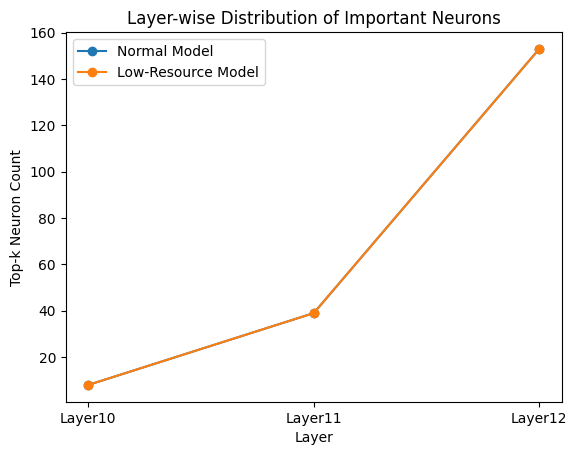

In [14]:
import matplotlib.pyplot as plt

layers = ['Layer10','Layer11','Layer12']

normal_vals = list(normal_layer_dist.values())
low_vals = list(low_layer_dist.values())

plt.plot(layers, normal_vals, marker='o', label="Normal Model")
plt.plot(layers, low_vals, marker='o', label="Low-Resource Model")

plt.xlabel("Layer")
plt.ylabel("Top-k Neuron Count")
plt.title("Layer-wise Distribution of Important Neurons")

plt.legend()
plt.show()

We analyzed the layer-wise distribution of the top-200 most important neurons across BERT layers 10–12. The majority of important neurons were concentrated in Layer 12, while Layers 10 and 11 contributed significantly fewer neurons. This indicates that higher transformer layers encode stronger task-specific representations for sentiment classification. The distribution pattern remained similar for both the full-data and low-resource models, suggesting structural consistency across training conditions.

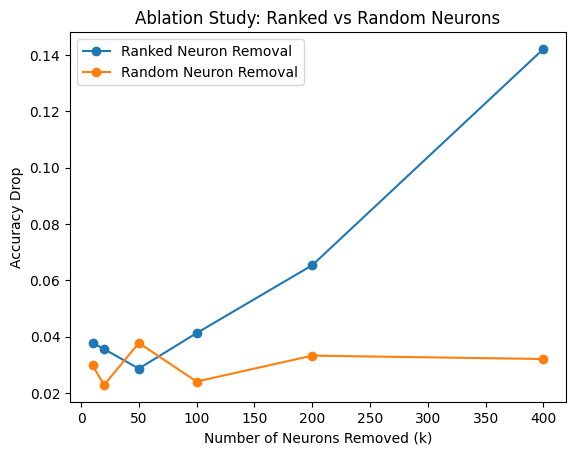

In [15]:
import matplotlib.pyplot as plt

k_values = [10,20,50,100,200,400]

ranked_drop = [0.0378,0.0356,0.0287,0.0413,0.0654,0.1422]
random_drop = [0.0298,0.0229,0.0378,0.0241,0.0333,0.0321]

plt.figure()

plt.plot(k_values, ranked_drop, marker='o', label="Ranked Neuron Removal")
plt.plot(k_values, random_drop, marker='o', label="Random Neuron Removal")

plt.xlabel("Number of Neurons Removed (k)")
plt.ylabel("Accuracy Drop")
plt.title("Ablation Study: Ranked vs Random Neurons")

plt.legend()
plt.show()

We visualized the results of the ablation experiments using plots and summary tables. The analysis shows that removing neurons ranked by importance causes a significantly larger accuracy drop compared to random neuron removal. This confirms that the proposed ranking method successfully identifies neurons that are causally important for the classification task.